In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub
path = kagglehub.dataset_download("johnsmith88/heart-disease-dataset")

Using Colab cache for faster access to the 'heart-disease-dataset' dataset.


In [3]:
df = pd.read_csv(path + '/heart.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [4]:
df['target'].value_counts()

,count
target,
1,526
0,499


In [5]:
df.drop_duplicates(inplace=True)

In [7]:
df['target'].value_counts()

,count
target,
1,164
0,138


In [11]:
X = df.drop('target', axis=1)
y = df['target']

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

lr_model = LogisticRegression(solver='liblinear', random_state=42)
dtc_model = DecisionTreeClassifier(random_state=42)

lr_model.fit(X_train, y_train)
dtc_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
y_pred_dtc = dtc_model.predict(X_test)

# Classification metrics

In [14]:
from sklearn.metrics import accuracy_score,confusion_matrix
print("Accuracy of Logistic Regression",accuracy_score(y_test,y_pred_lr))
print("Accuracy of Decision Trees",accuracy_score(y_test,y_pred_dtc))

Accuracy of Logistic Regression 0.8351648351648352
Accuracy of Decision Trees 0.7472527472527473


In [15]:
print("Logistic Regression Confusion Matrix\n")
pd.DataFrame(confusion_matrix(y_test,y_pred_lr),columns=list(range(0,2)))

Logistic Regression Confusion Matrix



,0,1
0,37,11
1,4,39


In [16]:
print("Decision Tree Confusion Matrix\n")
pd.DataFrame(confusion_matrix(y_test,y_pred_dtc),columns=list(range(0,2)))

Decision Tree Confusion Matrix



,0,1
0,35,13
1,10,33


In [17]:
from sklearn.metrics import precision_score,recall_score,f1_score

In [18]:
print("For Logistic regression Model")
print("-"*50)
cdf = pd.DataFrame(confusion_matrix(y_test,y_pred_lr),columns=list(range(0,2)))
print(cdf)
print("-"*50)
print("Precision - ",precision_score(y_test,y_pred_lr))
print("Recall - ",recall_score(y_test,y_pred_lr))
print("F1 score - ",f1_score(y_test,y_pred_lr))

For Logistic regression Model
--------------------------------------------------
    0   1
0  37  11
1   4  39
--------------------------------------------------
Precision -  0.78
Recall -  0.9069767441860465
F1 score -  0.8387096774193549


In [19]:
print("For DT Model")
print("-"*50)
cdf = pd.DataFrame(confusion_matrix(y_test,y_pred_dtc),columns=list(range(0,2)))
print(cdf)
print("-"*50)
print("Precision - ",precision_score(y_test,y_pred_dtc))
print("Recall - ",recall_score(y_test,y_pred_dtc))
print("F1 score - ",f1_score(y_test,y_pred_dtc))

For DT Model
--------------------------------------------------
    0   1
0  35  13
1  10  33
--------------------------------------------------
Precision -  0.717391304347826
Recall -  0.7674418604651163
F1 score -  0.7415730337078652


### Model Performance Comparison

**Logistic Regression Model:**
- **Accuracy:** 0.835
- **Precision:** 0.78
- **Recall:** 0.907
- **F1 Score:** 0.839

**Decision Tree Model:**
- **Accuracy:** 0.747
- **Precision:** 0.717
- **Recall:** 0.767
- **F1 Score:** 0.742

Based on these metrics, the Logistic Regression model generally performs better than the Decision Tree model on this dataset, showing higher accuracy, precision, recall, and F1 score.

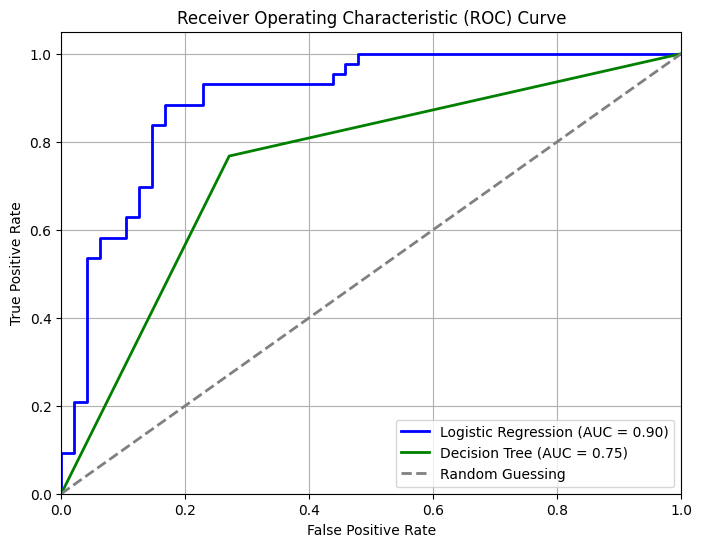

In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (class 1)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]
y_pred_proba_dtc = dtc_model.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC for Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

# Compute ROC curve and AUC for Decision Tree
fpr_dtc, tpr_dtc, _ = roc_curve(y_test, y_pred_proba_dtc)
roc_auc_dtc = auc(fpr_dtc, tpr_dtc)

# Plotting the ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')
plt.plot(fpr_dtc, tpr_dtc, color='green', lw=2, label=f'Decision Tree (AUC = {roc_auc_dtc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guessing')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()